
Sample Data:
    sno  age gender type  day_icu    outcome  smoking  alcohol  diabetes  \
0    1   81      M    E        2  DISCHARGE        0        0         1   
1    3   53      M    E        3  DISCHARGE        0        0         1   
2    5   60      F    E        9  DISCHARGE        0        0         0   
3    6   44      M    E        8  DISCHARGE        0        0         1   
4    7   56      F    E        2  DISCHARGE        0        0         1   

   hypertension  ...  chest_infection  count  haemoglobin  anaemia  \
0             0  ...                0      1          9.5        1   
1             0  ...                0      1         10.6        0   
2             1  ...                0      1         13.6        0   
3             1  ...                0      1         13.5        0   
4             1  ...                0      1         13.3        0   

   severe_anaemia  glucose  group_age  group_plate  group_leuk  group_ejectf  
0               0     80.0     76-

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:10:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Gradient Boosting...
Tuning Random Forest...
Best Params: {'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 300}

Ensemble Model Accuracy: 90.50%

Ensemble Classification Report:

              precision    recall  f1-score   support

        DAMA       1.00      0.09      0.17       111
   DISCHARGE       0.90      0.99      0.95      1396
      EXPIRY       0.91      0.67      0.77       146

    accuracy                           0.91      1653
   macro avg       0.94      0.59      0.63      1653
weighted avg       0.91      0.91      0.88      1653



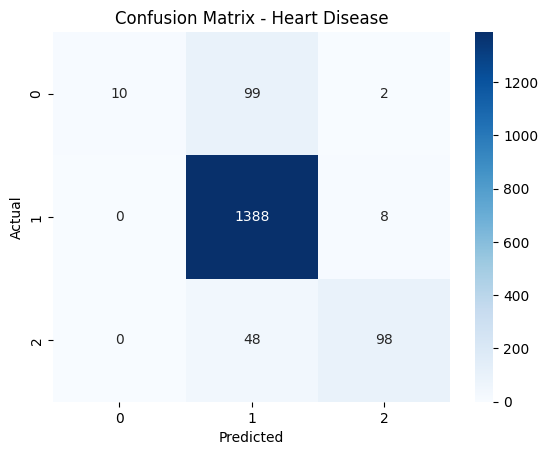

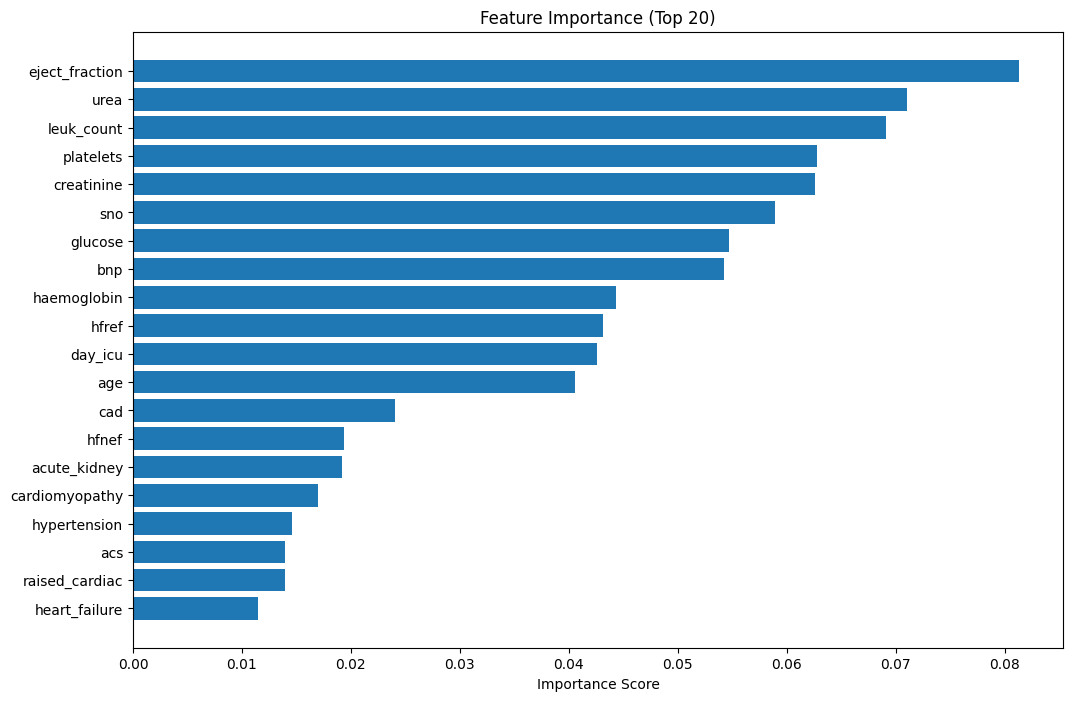

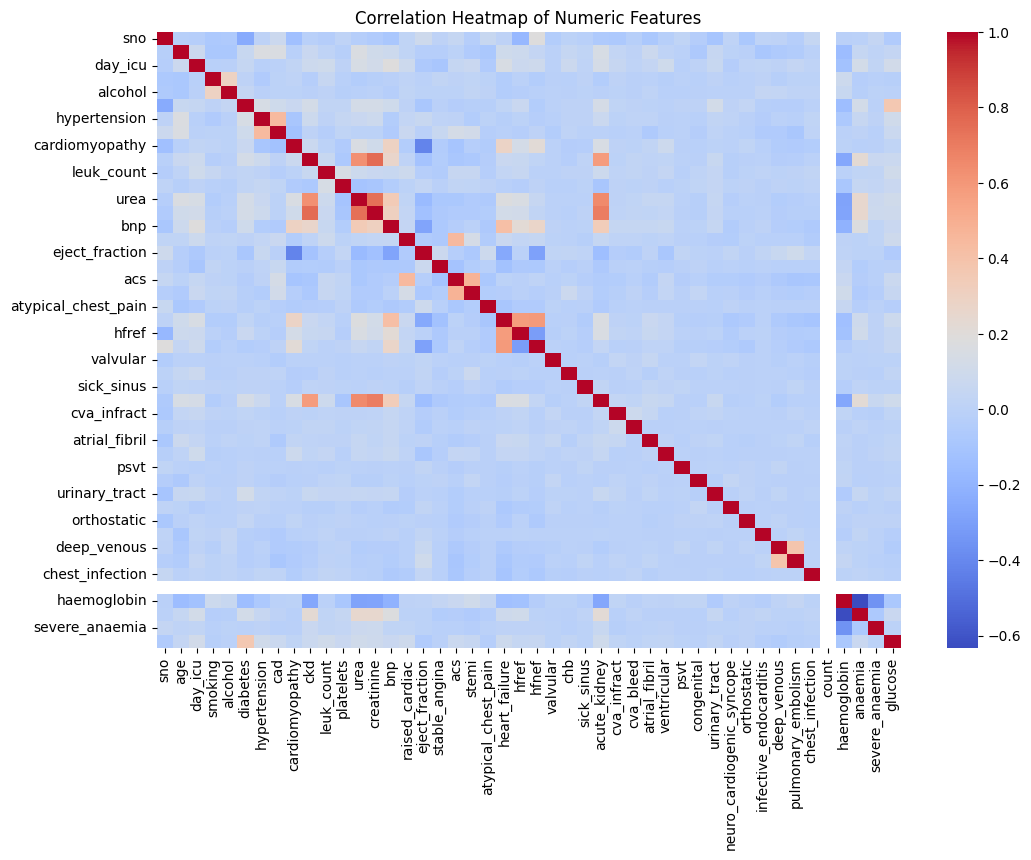

Enter SNo of patient for prediction: 81
{'SNo': 81, 'Prediction_Label': 'DISCHARGE', 'Diagnosis': '✔ Stable Condition', 'Used_Parameters': {'sno': 81, 'age': 40, 'gender': 'M', 'type': 'E', 'day_icu': 1, 'smoking': 0, 'alcohol': 0, 'diabetes': 0, 'hypertension': 0, 'cad': 1, 'cardiomyopathy': 0, 'ckd': 0, 'leuk_count': 13.3, 'platelets': 469.0, 'urea': 55.0, 'creatinine': 1.6, 'bnp': 593.0, 'raised_cardiac': 0, 'eject_fraction': 40, 'stable_angina': 0, 'acs': 1, 'stemi': 0, 'atypical_chest_pain': 0, 'heart_failure': 0, 'hfref': 0, 'hfnef': 0, 'valvular': 0, 'chb': 0, 'sick_sinus': 0, 'acute_kidney': 1, 'cva_infract': 0, 'cva_bleed': 0, 'atrial_fibril': 0, 'ventricular': 0, 'psvt': 0, 'congenital': 0, 'urinary_tract': 0, 'neuro_cardiogenic_syncope': 0, 'orthostatic': 0, 'infective_endocarditis': 0, 'deep_venous': 0, 'pulmonary_embolism': 0, 'chest_infection': 0, 'count': 1, 'haemoglobin': 15.3, 'anaemia': 0, 'severe_anaemia': 0, 'glucose': 87.0, 'group_age': '31-45', 'group_plate': 'hig

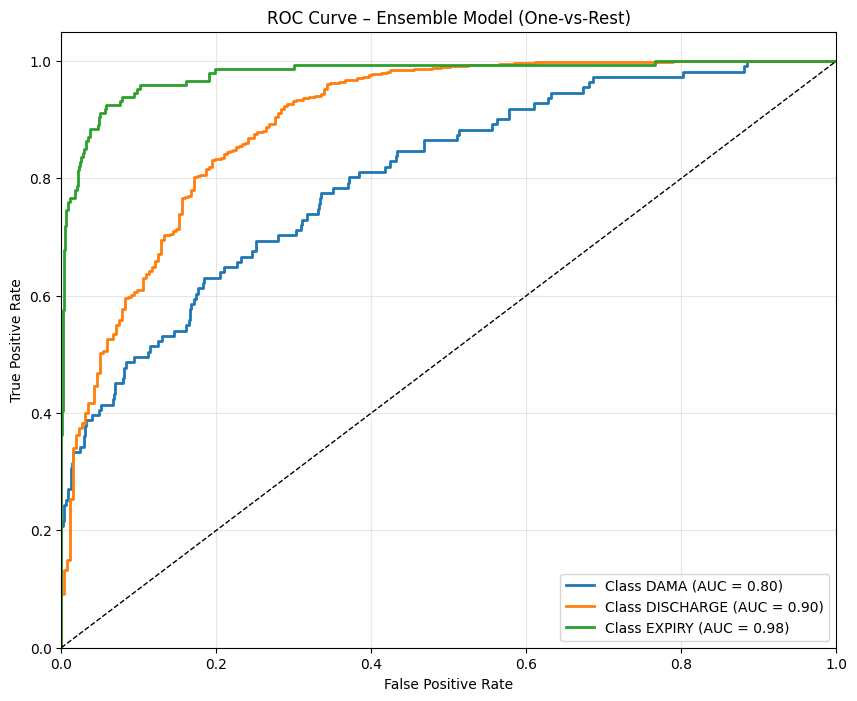

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


df = pd.read_csv("/content/DataClean-fullage.csv")
print("\nSample Data:\n", df.head())


target_col = "outcome"
label_encoder = LabelEncoder()
df[target_col] = label_encoder.fit_transform(df[target_col])

X = df.drop(target_col, axis=1)
y = df[target_col]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)



preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(onehot_feature_names)


def get_random_forest_model():
    model = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42)
    model.fit(X_train_processed, y_train)
    return model




def get_xgboost_model():
    model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        eval_metric="mlogloss",
        use_label_encoder=False
    )
    model.fit(X_train_processed, y_train)
    return model



def get_gradient_boost_model():
    model = GradientBoostingClassifier(random_state=42)
    model.fit(X_train_processed, y_train)
    return model




def tuned_random_forest():
    params = {
        "n_estimators": [200, 300, 400],
        "max_depth": [8, 10, 12],
        "min_samples_split": [2, 4],
    }
    grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        params,
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )
    grid.fit(X_train_processed, y_train)
    print("Best Params:", grid.best_params_)
    return grid.best_estimator_




def ensemble_predict(models, X_data_processed):
    preds = [m.predict(X_data_processed) for m in models]
    preds = np.array(preds)
    final = np.round(np.mean(preds, axis=0)).astype(int)
    return final



print("Training Random Forest...")
rf = get_random_forest_model()

print("Training XGBoost...")
xgb = get_xgboost_model()

print("Training Gradient Boosting...")
gb = get_gradient_boost_model()

print("Tuning Random Forest...")
rf_tuned = tuned_random_forest()

models = [rf, xgb, gb, rf_tuned]
ensemble_pred = ensemble_predict(models, X_test_processed)


ensemble_accuracy = accuracy_score(y_test, ensemble_pred) * 100
print(f"\nEnsemble Model Accuracy: {ensemble_accuracy:.2f}%")


print("\nEnsemble Classification Report:\n")
print(classification_report(y_test, ensemble_pred, target_names=label_encoder.classes_))


cm = confusion_matrix(y_test, ensemble_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Heart Disease")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


plt.figure(figsize=(12, 8))
importances = rf.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
top_n = min(len(all_feature_names), 20)

plt.barh([all_feature_names[i] for i in sorted_indices[:top_n]],
         importances[sorted_indices[:top_n]])
plt.gca().invert_yaxis()
plt.title(f"Feature Importance (Top {top_n})")
plt.xlabel("Importance Score")
plt.show()


plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()



def predict_patient_status_by_sno(sno):
    if "sno" not in df.columns:
        return {"Error": "'sno' column not found in dataset."}

    if sno not in df["sno"].values:
        return {"Error": f"SNo {sno} not found in dataset."}

    row = df[df["sno"] == sno].iloc[0]
    patient_dict = row.drop(target_col).to_dict()

    input_df = pd.DataFrame([patient_dict])
    input_df = input_df[X.columns]

    input_processed = preprocessor.transform(input_df)

    preds = [m.predict(input_processed) for m in models]
    final_pred_label = int(np.round(np.mean(preds)))
    original_label = label_encoder.inverse_transform([final_pred_label])[0]

    if original_label == "EXPIRY":
        diagnosis = "⚠ High Risk of Heart Disease"
    elif original_label == "DAMA":
        diagnosis = "⚠ Moderate Risk of Heart Disease"
    elif original_label == "DISCHARGE":
        diagnosis = "✔ Stable Condition"
    else:
        diagnosis = "Unknown Status"

    return {
        "SNo": sno,
        "Prediction_Label": original_label,
        "Diagnosis": diagnosis,
        "Used_Parameters": patient_dict
    }

sno_input = int(input("Enter SNo of patient for prediction: "))
result = predict_patient_status_by_sno(sno_input)
print(result)

print("\n----- Individual Model Accuracies -----\n")


rf_pred = rf.predict(X_test_processed)
rf_acc = accuracy_score(y_test, rf_pred) * 100
print(f"Random Forest Accuracy: {rf_acc:.2f}%")


xgb_pred = xgb.predict(X_test_processed)
xgb_acc = accuracy_score(y_test, xgb_pred) * 100
print(f"XGBoost Accuracy: {xgb_acc:.2f}%")


gb_pred = gb.predict(X_test_processed)
gb_acc = accuracy_score(y_test, gb_pred) * 100
print(f"Gradient Boosting Accuracy: {gb_acc:.2f}%")


rf_tuned_pred = rf_tuned.predict(X_test_processed)
rf_tuned_acc = accuracy_score(y_test, rf_tuned_pred) * 100
print(f"Tuned Random Forest Accuracy: {rf_tuned_acc:.2f}%")

print("\n----- Ensemble Accuracy -----\n")
print(f"Ensemble Model Accuracy: {ensemble_accuracy:.2f}%")

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]


probs = [m.predict_proba(X_test_processed) for m in models]
avg_proba = np.mean(probs, axis=0)

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], avg_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2,
             label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Ensemble Model (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

